In [2]:
# Import statements
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt



In [3]:
final_df = pd.read_csv('final_merged_output.csv')


In [4]:
final_df = final_df[(final_df['Year'] < 2023)]

In [5]:
features = ['Median Household Income', 'Total Population', 'INDPRO', 'VIXCLS', 'CPI', 'Unemployment Rate', 'City GDP']
scaler = StandardScaler()

final_df[features] = final_df.groupby('City')[features].transform(lambda x: (x - x.mean()) / x.std())


In [6]:


results = {}

for city, city_df in final_df.groupby('City'):
    X = city_df[features]
    y = city_df['index_nsa']
    X = sm.add_constant(X)  

    model = sm.OLS(y, X).fit()
    results[city] = model
    print(f"{city} — R²: {model.rsquared:.3f}, Adj. R²: {model.rsquared_adj:.3f}")
    print(model.summary())

Chicago — R²: 0.904, Adj. R²: 0.898
                            OLS Regression Results                            
Dep. Variable:              index_nsa   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     166.5
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           6.69e-60
Time:                        14:08:44   Log-Likelihood:                -518.19
No. Observations:                 132   AIC:                             1052.
Df Residuals:                     124   BIC:                             1075.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [ ]:
final_df['ols_predicted_hpi'] = final_df.groupby('City').apply(
    lambda g: results[g.name].predict(sm.add_constant(g[features]))
).reset_index(level=0, drop=True)

final_df['residual'] = final_df['index_nsa'] - final_df['ols_predicted_hpi']

C:\Users\deepi\AppData\Local\Temp\ipykernel_32552\3710126620.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_df['predicted_hpi'] = final_df.groupby('City').apply(


In [8]:



p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_orders = {}
arima_results = {}

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter'])
    residuals = city_df['residual'].dropna()

    best_aic = np.inf
    best_order = None
    best_model = None

    for order in pdq:
        try:
            model = ARIMA(residuals, order=order)
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = order
                best_model = fitted
        except Exception:
            continue

    best_orders[city] = best_order
    arima_results[city] = best_model
    print(f"{city}: best order = {best_order}, AIC = {best_aic:.2f}")

c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as st

Chicago: best order = (0, 1, 0), AIC = 823.44


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib

Houston: best order = (1, 1, 1), AIC = 752.52


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib

Los Angeles: best order = (1, 1, 1), AIC = 1069.05


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib

New York: best order = (2, 1, 1), AIC = 973.45


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib

Phoenix: best order = (2, 1, 2), AIC = 1065.01


In [9]:
for city, city_df in final_df.groupby('City'):
    regression_pred = results[city].predict(sm.add_constant(city_df[features]))
    arima_pred = arima_results[city].predict()
    
    final_df.loc[city_df.index, 'noise_hpi_forecast'] = regression_pred + arima_pred

In [10]:

#HPI arima
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_orders_raw = {}
arima_results_raw = {}

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter'])
    series = city_df['index_nsa'].dropna()

    best_aic = np.inf
    best_order = None
    best_model = None

    for order in pdq:
        try:
            model = ARIMA(series, order=order)
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = order
                best_model = fitted
        except Exception:
            continue

    best_orders_raw[city] = best_order
    arima_results_raw[city] = best_model
    print(f"{city}: best ARIMA order = {best_order}, AIC = {best_aic:.2f}")

final_df['arima_predicted_hpi'] = np.nan

for city, city_df in final_df.groupby('City'):
    fitted = arima_results_raw[city]
    preds = fitted.fittedvalues
    final_df.loc[city_df.iloc[-len(preds):].index, 'arima_predicted_hpi'] = preds


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using

Chicago: best ARIMA order = (2, 2, 0), AIC = 513.95


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib

Houston: best ARIMA order = (2, 2, 2), AIC = 526.34


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib

Los Angeles: best ARIMA order = (2, 2, 1), AIC = 755.49


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib

New York: best ARIMA order = (2, 2, 0), AIC = 589.38


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib

Phoenix: best ARIMA order = (2, 2, 2), AIC = 791.31


In [11]:
print(final_df)

        City  Year  Quarter  index_nsa  Median Household Income  \
0    Chicago  1990        1      83.83                -1.503776   
1    Chicago  1990        2      84.81                -1.503776   
2    Chicago  1990        3      85.80                -1.503776   
3    Chicago  1990        4      85.87                -1.503776   
4    Chicago  1991        1      86.95                -1.477975   
..       ...   ...      ...        ...                      ...   
695  Phoenix  2021        4     435.76                 2.378480   
696  Phoenix  2022        1     457.57                 2.560574   
697  Phoenix  2022        2     495.27                 2.742668   
698  Phoenix  2022        3     502.20                 2.924762   
699  Phoenix  2022        4     478.18                 3.106857   

     Total Population    INDPRO    VIXCLS       CPI  Unemployment Rate  \
0            0.068244 -2.078336  0.355232  1.836914           0.057305   
1            0.068244 -2.044978 -0.129633  1.83

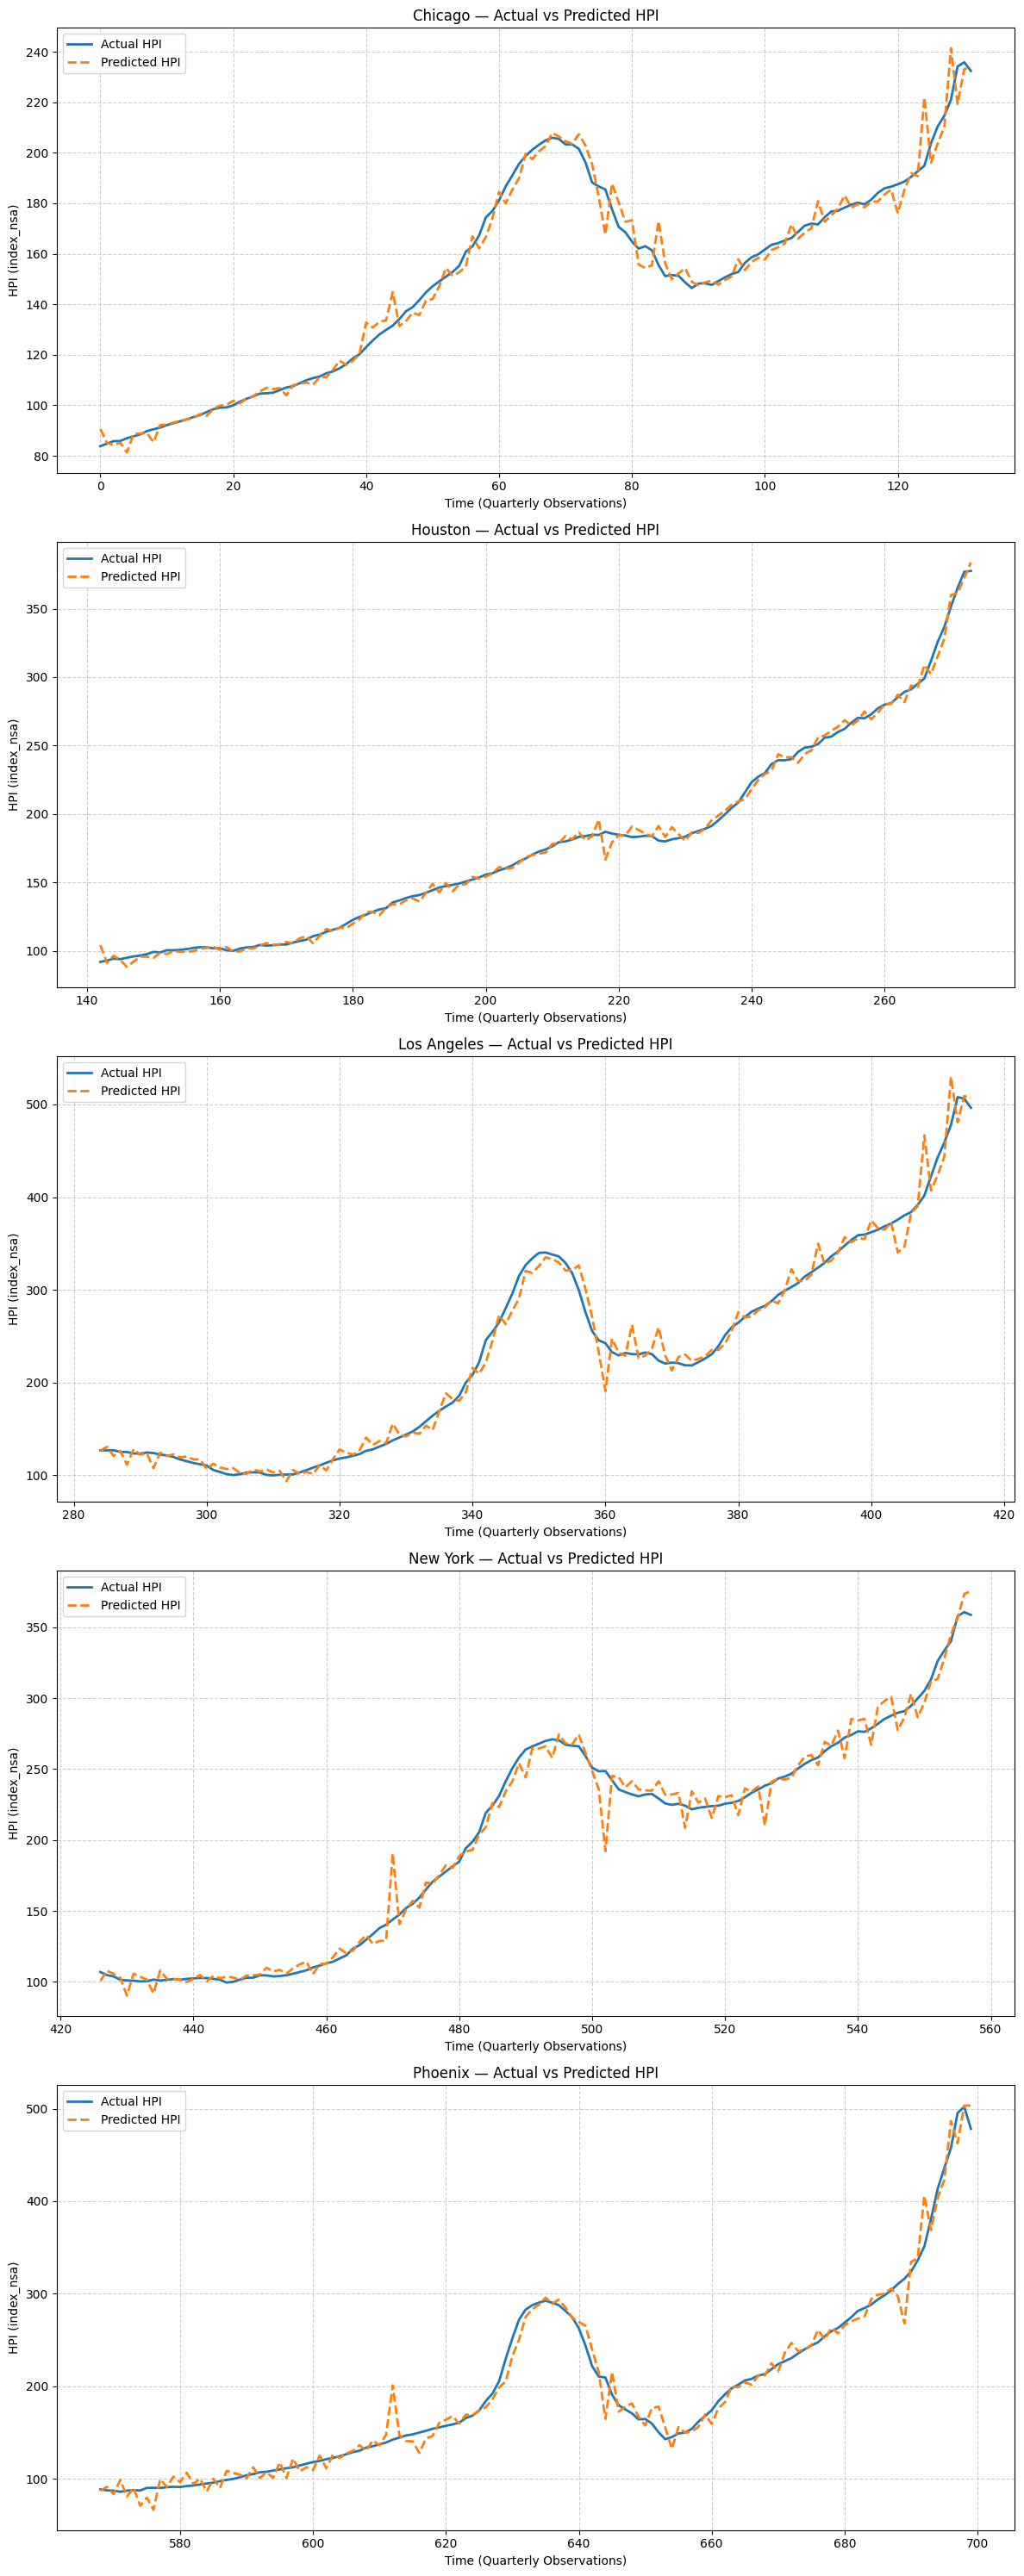

In [ ]:


final_df = final_df.sort_values(['City', 'Year', 'Quarter'])

cities = final_df['City'].unique()

plt.figure(figsize=(12, 6 * len(cities)))

for i, city in enumerate(cities, 1):
    city_df = final_df[final_df['City'] == city]

    plt.subplot(len(cities), 1, i)
    plt.plot(
        city_df.index, city_df['index_nsa'],
        label='Actual HPI', linewidth=2
    )
    plt.plot(
        city_df.index, city_df['noise_hpi_forecast'],
        label='Hybrid Predicted HPI', linestyle='--', linewidth=2
    )

    plt.title(f"{city} — Actual vs Hybrid Predicted HPI")
    plt.xlabel("Time (Quarterly Observations)")
    plt.ylabel("HPI (index_nsa)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


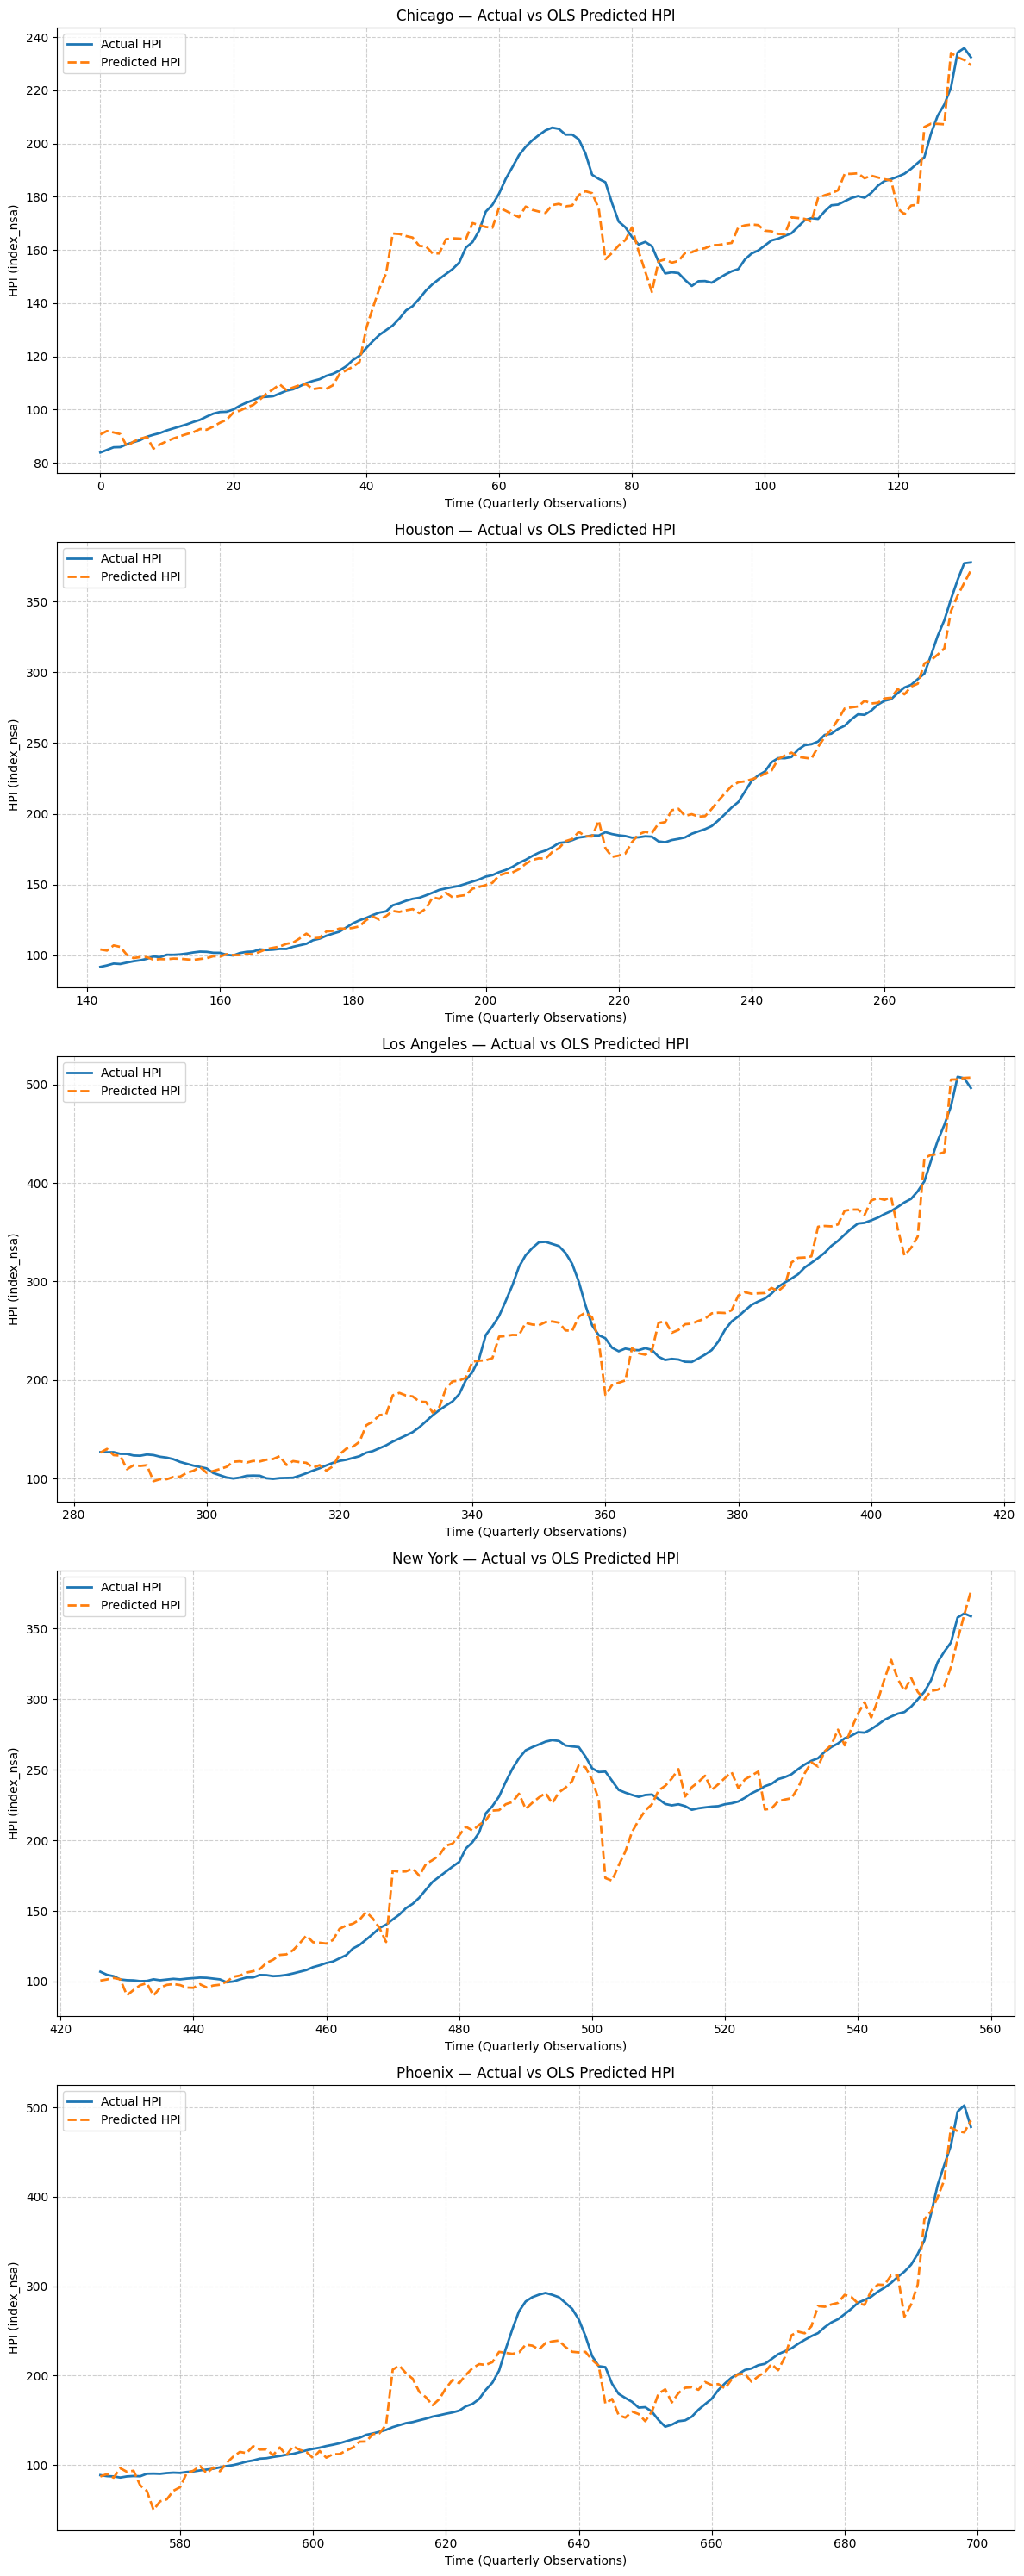

In [ ]:



cities = final_df['City'].unique()

plt.figure(figsize=(12, 6 * len(cities)))

for i, city in enumerate(cities, 1):
    city_df = final_df[final_df['City'] == city]

    plt.subplot(len(cities), 1, i)
    plt.plot(
        city_df.index, city_df['index_nsa'],
        label='Actual HPI', linewidth=2
    )
    plt.plot(
        city_df.index, city_df['ols_predicted_hpi'],
        label='Predicted HPI', linestyle='--', linewidth=2
    )

    plt.title(f"{city} — Actual vs OLS Predicted HPI")
    plt.xlabel("Time (Quarterly Observations)")
    plt.ylabel("HPI (index_nsa)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [25]:


#training on 90%

features = [
    'Median Household Income', 'Total Population', 'INDPRO',
    'VIXCLS', 'CPI', 'Unemployment Rate', 'City GDP'
]

results_summary = []

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter']).reset_index(drop=True)

    train_size = int(len(city_df) * 0.9)
    train_df = city_df.iloc[:train_size]
    test_df = city_df.iloc[train_size:]

    # ols
    X_train = sm.add_constant(train_df[features])
    y_train = train_df['index_nsa']
    X_test = sm.add_constant(test_df[features])

    ols_model = sm.OLS(y_train, X_train).fit()
    ols_pred_train = ols_model.predict(X_train)
    ols_pred_test = ols_model.predict(X_test)

    ols_mae = mean_absolute_error(test_df['index_nsa'], ols_pred_test)
    ols_rmse = np.sqrt(mean_squared_error(test_df['index_nsa'], ols_pred_test))

    # noise arima
    residuals_train = y_train - ols_pred_train
    order = best_orders.get(city, (1, 1, 1))  

    try:
        arima_model = ARIMA(residuals_train, order=order)
        arima_fit = arima_model.fit()
        arima_forecast = arima_fit.forecast(steps=len(test_df))

        hybrid_forecast = ols_pred_test + arima_forecast.values
        hybrid_mae = mean_absolute_error(test_df['index_nsa'], hybrid_forecast)
        hybrid_rmse = np.sqrt(mean_squared_error(test_df['index_nsa'], hybrid_forecast))
    except Exception as e:
        hybrid_mae, hybrid_rmse = np.nan, np.nan

    # HPI arima
    try:
        arima_model_hpi = ARIMA(train_df['index_nsa'], order=best_orders_raw.get(city))
        arima_fit_hpi = arima_model_hpi.fit()
        arima_forecast_only = arima_fit_hpi.forecast(steps=len(test_df))

        arima_mae = mean_absolute_error(test_df['index_nsa'], arima_forecast_only)
        arima_rmse = np.sqrt(mean_squared_error(test_df['index_nsa'], arima_forecast_only))
    except Exception as e:
        arima_mae, arima_rmse = np.nan, np.nan

    results_summary.append({
        'City': city,
        'OLS_MAE': round(ols_mae, 2),
        'OLS_RMSE': round(ols_rmse, 2),
        'Hybrid_MAE': round(hybrid_mae, 2),
        'Hybrid_RMSE': round(hybrid_rmse, 2),
        'ARIMA_MAE': round(arima_mae, 2),
        'ARIMA_RMSE': round(arima_rmse, 2),
        'ARIMA Order Used - Noise': order,
        'ARIMA Order Used - HPI': best_orders_raw.get(city),
    })

results_df = pd.DataFrame(results_summary)
print(results_df)

c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


          City  OLS_MAE  OLS_RMSE  Hybrid_MAE  Hybrid_RMSE  ARIMA_MAE  \
0      Chicago    35.67     38.32       28.35        31.61      11.45   
1      Houston    39.46     45.73       31.14        38.78      22.63   
2  Los Angeles    42.35     54.49       43.64        57.79      49.79   
3     New York    32.91     37.08       27.51        29.88      20.26   
4      Phoenix   137.52    155.18      111.98       133.04      55.60   

   ARIMA_RMSE ARIMA Order Used - Noise ARIMA Order Used - HPI  
0       16.97                (0, 1, 0)              (2, 2, 0)  
1       33.48                (1, 1, 1)              (2, 2, 2)  
2       66.53                (1, 1, 1)              (2, 2, 1)  
3       27.87                (2, 1, 1)              (2, 2, 0)  
4       77.60                (2, 1, 2)              (2, 2, 2)  


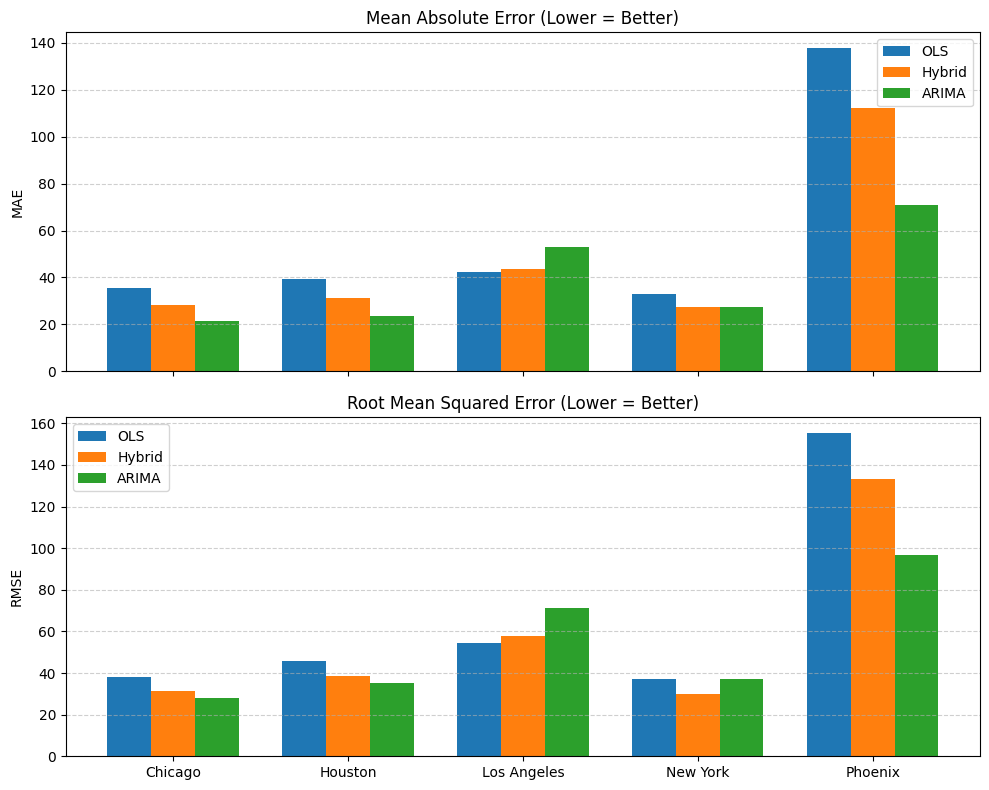

In [15]:


for col in ['OLS_MAE', 'OLS_RMSE', 'Hybrid_MAE', 'Hybrid_RMSE', 'ARIMA_MAE', 'ARIMA_RMSE']:
    results_df[col] = results_df[col].astype(float)

cities = results_df['City']
x = np.arange(len(cities))
width = 0.25

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)


ax[0].bar(x - width, results_df['OLS_MAE'], width, label='OLS')
ax[0].bar(x, results_df['Hybrid_MAE'], width, label='Hybrid')
ax[0].bar(x + width, results_df['ARIMA_MAE'], width, label='ARIMA')
ax[0].set_ylabel('MAE')
ax[0].set_title('Mean Absolute Error (Lower = Better)')
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

ax[1].bar(x - width, results_df['OLS_RMSE'], width, label='OLS')
ax[1].bar(x, results_df['Hybrid_RMSE'], width, label='Hybrid')
ax[1].bar(x + width, results_df['ARIMA_RMSE'], width, label='ARIMA')
ax[1].set_ylabel('RMSE')
ax[1].set_title('Root Mean Squared Error (Lower = Better)')
ax[1].set_xticks(x)
ax[1].set_xticklabels(cities)
ax[1].legend()
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:


tscv = TimeSeriesSplit(n_splits=5)
pdq = list(itertools.product(range(0,3), range(0,3), range(0,3)))  
cv_results = []
#cross validation - time series splits for rolling windows, repeating averahe performance
for city, city_df in final_df.groupby("City"):
    city_df = city_df.sort_values(["Year","Quarter"]).reset_index(drop=True)
    X = city_df[features]
    y = city_df["index_nsa"]

    fold_id = 1
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        #OLS

        X_train_c, X_test_c = sm.add_constant(X_train, has_constant="add"), sm.add_constant(X_test, has_constant="add")
        ols_model = sm.OLS(y_train, X_train_c).fit()
        ols_pred = ols_model.predict(X_test_c)

        ols_mae = mean_absolute_error(y_test, ols_pred)
        ols_rmse = np.sqrt(mean_squared_error(y_test, ols_pred))
        ols_mape = mean_absolute_percentage_error(y_test, ols_pred) * 100

        #noise arima
        train_resid = y_train - ols_model.predict(X_train_c)

        best_aic, best_order, best_model = np.inf, None, None
        best_order = best_orders.get(city)
        best_model = ARIMA(train_resid, order=best_order).fit()

        hybrid_resid_forecast = best_model.forecast(steps=len(y_test))
        hybrid_forecast = ols_pred + hybrid_resid_forecast

        hybrid_mae = mean_absolute_error(y_test, hybrid_forecast)
        hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_forecast))
        hybrid_mape = mean_absolute_percentage_error(y_test, hybrid_forecast) * 100
        
        
        # hpi arima
        best_aic, best_order_raw, best_model_raw = np.inf, None, None
        best_model_raw = ARIMA(y_train, order=best_orders_raw.get(city)).fit()
        # for order in pdq:
        #     try:
        #         model = ARIMA(y_train, order=order).fit()
        #         if model.aic < best_aic:
        #             best_aic, best_order_raw, best_model_raw = model.aic, order, model
        #     except:
        #         continue

        arima_forecast = best_model_raw.forecast(steps=len(y_test))
        arima_mae = mean_absolute_error(y_test, arima_forecast)
        arima_rmse = np.sqrt(mean_squared_error(y_test, arima_forecast))
        arima_mape = mean_absolute_percentage_error(y_test, arima_forecast) * 100
        
        cv_results.append({
            "City": city,
            "Fold": fold_id,
            "OLS_MAE": ols_mae,
            "OLS_RMSE": ols_rmse,
            "OLS_MAPE": ols_mape,
            "Hybrid_MAE": hybrid_mae,
            "Hybrid_RMSE": hybrid_rmse,
            "Hybrid_MAPE": hybrid_mape,
            "ARIMA_MAE": arima_mae,
            "ARIMA_RMSE": arima_rmse,
            "ARIMA_MAPE": arima_mape,
            "Hybrid_ARIMA_Order": best_order,
            "HPI_ARIMA_Order": best_orders_raw
        })
        fold_id += 1

cv_df = pd.DataFrame(cv_results)

print(cv_df)
print(cv_df.groupby("City")[["OLS_RMSE","Hybrid_RMSE","ARIMA_RMSE"]].mean().round(2))
print(cv_df.groupby("City")[["OLS_MAPE","Hybrid_MAPE","ARIMA_MAPE"]].mean().round(2))
#print(cv_df.groupby("City")[["OLS_RMSE","Hybrid_RMSE","ARIMA_RMSE"]].mean().round(2))


c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using

           City  Fold     OLS_MAE    OLS_RMSE    OLS_MAPE  Hybrid_MAE  \
0       Chicago     1    2.333221    3.921675    1.955276    2.417281   
1       Chicago     2   16.247140   19.236732   10.977596   16.337367   
2       Chicago     3   36.836438   53.330151   23.017724   39.776649   
3       Chicago     4   53.273592   54.401903   33.237298   34.169363   
4       Chicago     5   26.373586   33.541967   12.928252   27.259342   
5       Houston     1    9.705936   12.344186    8.056967    9.705687   
6       Houston     2  117.662296  124.741307   76.479997  117.771080   
7       Houston     3    7.430754    9.061016    4.077438    7.038998   
8       Houston     4    9.896123   11.636840    4.817282    6.524459   
9       Houston     5   29.597461   39.918147    8.977483   25.477398   
10  Los Angeles     1   38.731041   48.146589   32.506521   38.708202   
11  Los Angeles     2  165.456196  172.840312   77.634701  168.924250   
12  Los Angeles     3  117.780441  136.357474   49.

c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


          City  OLS_MAE  OLS_RMSE  OLS_MAPE  Hybrid_MAE  Hybrid_RMSE  \
0      Chicago    27.01     32.89     16.42       23.99        30.00   
1      Houston    34.86     39.54     20.48       33.30        38.17   
2  Los Angeles   107.50    119.38     46.17      106.57       120.06   
3     New York   145.33    177.48     65.33      144.39       177.23   
4      Phoenix    77.57     99.42     27.66       69.81        92.18   

   Hybrid_MAPE  ARIMA_MAE  ARIMA_RMSE  ARIMA_MAPE  
0        14.48      20.73       26.03       12.34  
1        19.78      14.91       20.03        6.89  
2        46.12      65.88       81.50       26.58  
3        64.94      26.16       32.72       11.47  
4        25.72      43.03       56.57       21.62  
          City  OLS_MAE  OLS_RMSE  OLS_MAPE  Hybrid_MAE  Hybrid_RMSE  \
0      Chicago    27.01     32.89     16.42       23.99        30.00   
1      Houston    34.86     39.54     20.48       33.30        38.17   
2  Los Angeles   107.50    119.38     4

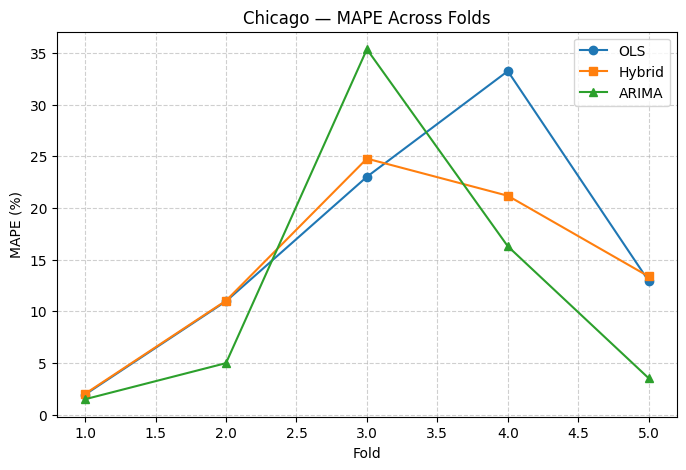

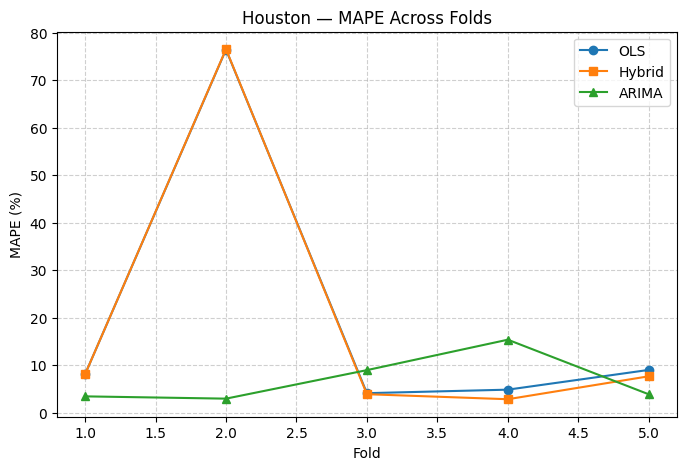

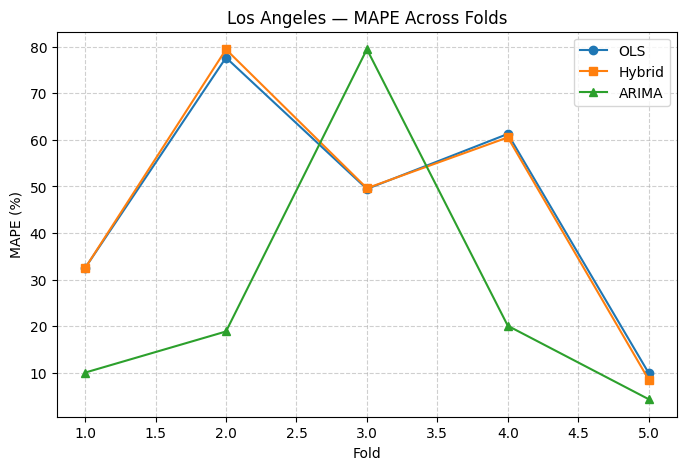

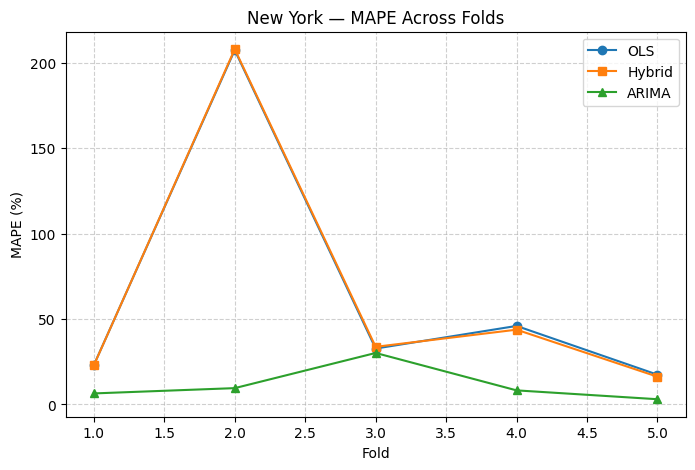

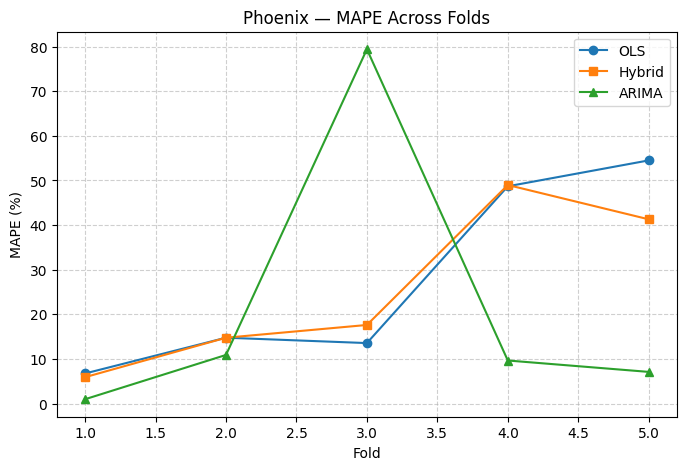

In [38]:
cv_summary = cv_df.groupby("City")[[
    "OLS_MAE", "OLS_RMSE", "OLS_MAPE",
    "Hybrid_MAE", "Hybrid_RMSE", "Hybrid_MAPE",
    "ARIMA_MAE", "ARIMA_RMSE", "ARIMA_MAPE"
]].mean().reset_index()

print(cv_summary.round(2))

cv_std = cv_df.groupby("City")[[
    "OLS_RMSE", "Hybrid_RMSE", "ARIMA_RMSE",
    "OLS_MAPE", "Hybrid_MAPE", "ARIMA_MAPE"
]].std().add_suffix("_std").reset_index()

cv_summary = cv_summary.merge(cv_std, on="City")
print(cv_summary.round(2))

import matplotlib.pyplot as plt
import numpy as np

for city in cv_df["City"].unique():
    subset = cv_df[cv_df["City"] == city]
    plt.figure(figsize=(8,5))
    plt.plot(subset["Fold"], subset["OLS_MAPE"], marker='o', label="OLS")
    plt.plot(subset["Fold"], subset["Hybrid_MAPE"], marker='s', label="Hybrid")
    plt.plot(subset["Fold"], subset["ARIMA_MAPE"], marker='^', label="ARIMA")
    plt.title(f"{city} — MAPE Across Folds")
    plt.xlabel("Fold")
    plt.ylabel("MAPE (%)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()




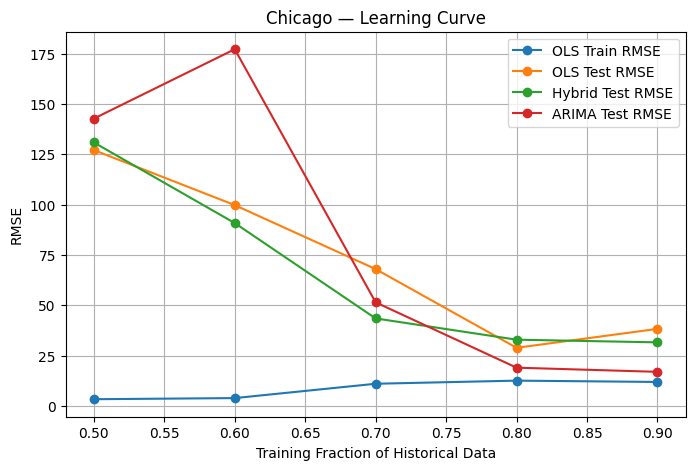

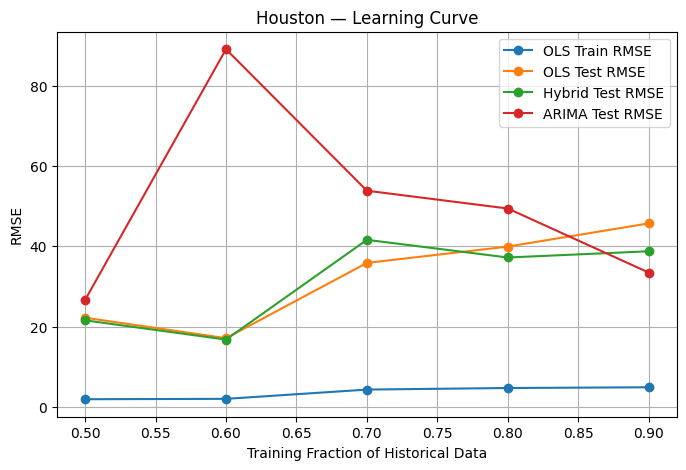

c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. 

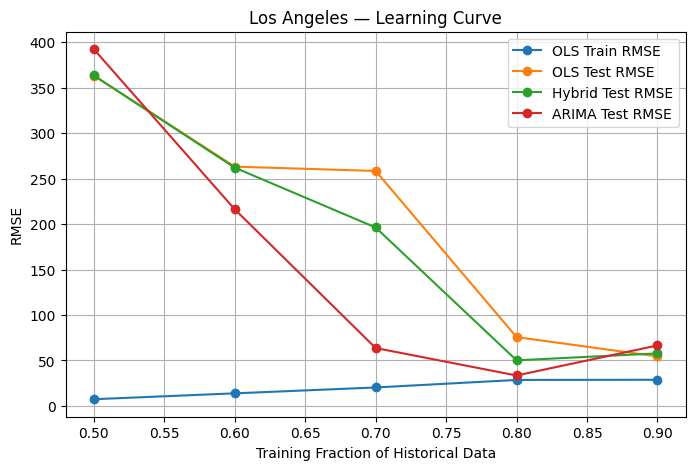

c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. 

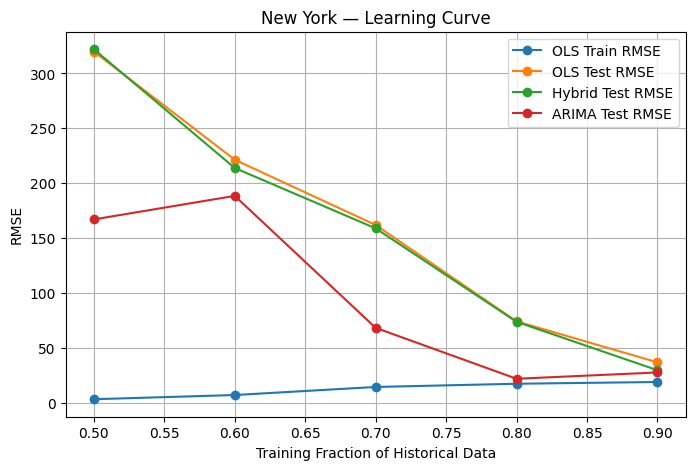

c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\deepi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


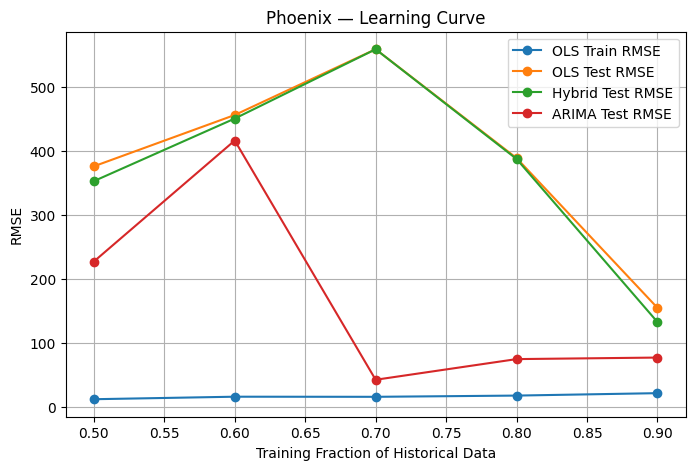

In [34]:


for city, city_df in final_df.groupby("City"):
    city_df = city_df.sort_values(["Year","Quarter"]).reset_index(drop=True)
    y = city_df["index_nsa"]

    train_fracs = np.linspace(0.5, 0.9, 5)
    ols_rmse_train, ols_rmse_test = [], []
    hybrid_rmse_test, arima_rmse_test = [], []

    for frac in train_fracs:
        split = int(len(city_df) * frac)
        train, test = city_df.iloc[:split], city_df.iloc[split:]
        X_train, X_test = sm.add_constant(train[features], has_constant="add"), sm.add_constant(test[features], has_constant="add")
        y_train, y_test = train["index_nsa"], test["index_nsa"]

        # ols
        ols_model = sm.OLS(y_train, X_train).fit()
        y_pred_train = ols_model.predict(X_train)
        y_pred_test = ols_model.predict(X_test)
        ols_rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
        ols_rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

        # arima on ols
        resid_train = y_train - y_pred_train
        best_aic, best_model = np.inf, None
        best_model = ARIMA(resid_train, order=best_orders.get(city)).fit()
        hybrid_forecast = y_pred_test + best_model.forecast(steps=len(y_test))
        hybrid_rmse_test.append(np.sqrt(mean_squared_error(y_test, hybrid_forecast)))

        # arima on hpi
        best_aic, best_model = np.inf, None
        best_model = ARIMA(y_train, order=best_orders_raw.get(city)).fit()
        arima_forecast = best_model.forecast(steps=len(y_test))
        arima_rmse_test.append(np.sqrt(mean_squared_error(y_test, arima_forecast)))

    plt.figure(figsize=(8,5))
    plt.plot(train_fracs, ols_rmse_train, "o-", label="OLS Train RMSE")
    plt.plot(train_fracs, ols_rmse_test, "o-", label="OLS Test RMSE")
    plt.plot(train_fracs, hybrid_rmse_test, "o-", label="Hybrid Test RMSE")
    plt.plot(train_fracs, arima_rmse_test, "o-", label="ARIMA Test RMSE")
    plt.title(f"{city} — Learning Curve")
    plt.xlabel("Training Fraction of Historical Data")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()
